✅ DATA AMAN & SIAP DI-PLOT!


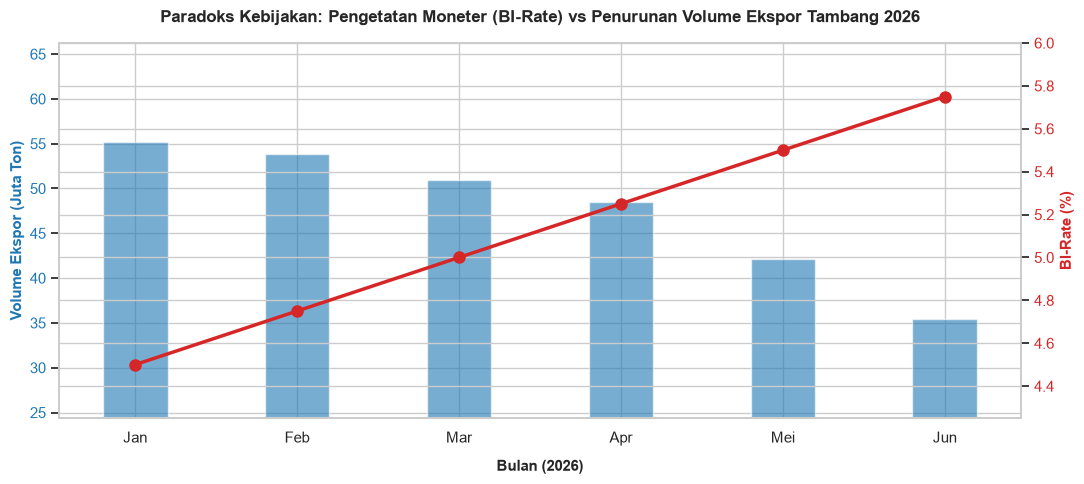

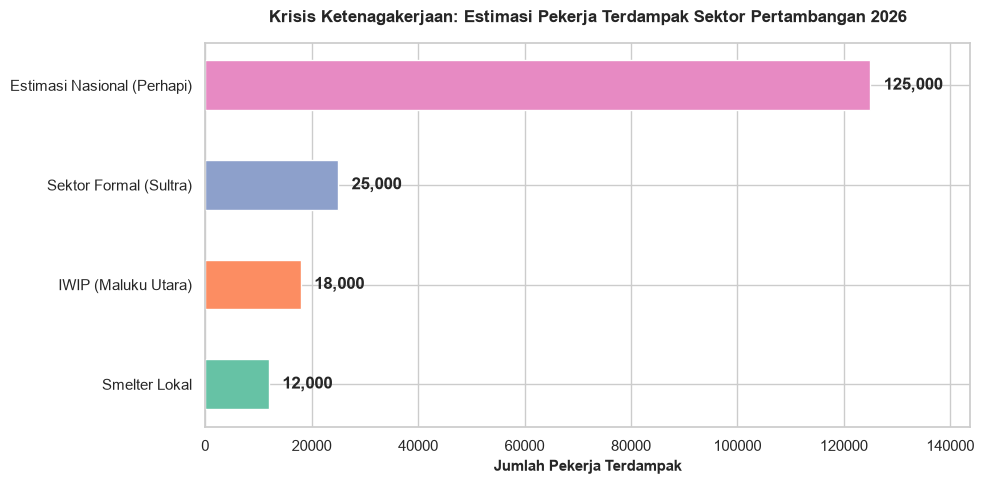

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid") #ini buat ngatur tema visualisasi yah

# 2. Setup Jalur Folder (Mundur dari 'src' ke folder utama)
base_dir = os.path.dirname(os.path.abspath('__file__'))
if os.path.basename(base_dir) == 'src':
    data_folder = os.path.join(base_dir, '..', 'data')
else:
    data_folder = os.path.join(base_dir, 'data')

os.makedirs(data_folder, exist_ok=True)

path_makro = os.path.join(data_folder, 'data_makro.csv')
path_phk = os.path.join(data_folder, 'data_dampak_phk.csv')

# 3. MENTRIGGER PENGECEKAN & PENGISIAN DATA JIKA KOSONG

#ini Data Makroekonomi 2026
data_makro_asli = {
    'Bulan': ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun'],
    'BI_Rate_Persen': [4.5, 4.75, 5.0, 5.25, 5.5, 5.75],
    'Vol_Ekspor_Juta_Ton': [55.2, 53.8, 51.0, 48.5, 42.1, 35.4]
}

#Data Dampak PHK Pertambangan 2026
data_phk_asli = {
    'Entitas_Daerah': ['IWIP (Maluku Utara)', 'Sektor Formal (Sultra)', 'Smelter Lokal', 'Estimasi Nasional (Perhapi)'],
    'Pekerja_Terdampak': [18000, 25000, 12000, 125000]
}

# Cek & Tulis Ulang jika file kosong/tidak ada
try:
    if not os.path.exists(path_makro) or os.path.getsize(path_makro) < 10:
        pd.DataFrame(data_makro_asli).to_csv(path_makro, index=False)
        print("⚡ File data_makro.csv kosong/tidak ditemukan. Isinya sudah berhasil dibuat ulang!")
    
    if not os.path.exists(path_phk) or os.path.getsize(path_phk) < 10:
        pd.DataFrame(data_phk_asli).to_csv(path_phk, index=False)
        print("⚡ File data_dampak_phk.csv kosong/tidak ditemukan. Isinya sudah berhasil dibuat ulang!")

    #Load data yang sudah dipastikan aman
    df_makro = pd.read_csv(path_makro)
    df_phk = pd.read_csv(path_phk)
    print("✅ DATA AMAN & SIAP DI-PLOT!")

except Exception as e:
    print(f"Terjadi kendala saat menulis ulang data: {e}")

#BAGIAN 1: BI-RATE VS VOLUME EKSPOR
fig, ax1 = plt.subplots(figsize=(11, 5))

color_bar = '#1f77b4'
ax1.set_xlabel('Bulan (2026)', fontsize=11, fontweight='bold', labelpad=10)
ax1.set_ylabel('Volume Ekspor (Juta Ton)', color=color_bar, fontsize=11, fontweight='bold')
ax1.bar(df_makro['Bulan'], df_makro['Vol_Ekspor_Juta_Ton'], color=color_bar, alpha=0.6, width=0.4)
ax1.tick_params(axis='y', labelcolor=color_bar)

vol_min, vol_max = df_makro['Vol_Ekspor_Juta_Ton'].min(), df_makro['Vol_Ekspor_Juta_Ton'].max()
vol_margin = (vol_max - min(0, vol_min)) * 0.2
ax1.set_ylim(max(0, vol_min - vol_margin), vol_max + vol_margin)

ax2 = ax1.twinx()
color_line = '#d62728'
ax2.set_ylabel('BI-Rate (%)', color=color_line, fontsize=11, fontweight='bold')
ax2.plot(df_makro['Bulan'], df_makro['BI_Rate_Persen'], color=color_line, marker='o', linewidth=2.5, markersize=8)
ax2.tick_params(axis='y', labelcolor=color_line)

rate_min, rate_max = df_makro['BI_Rate_Persen'].min(), df_makro['BI_Rate_Persen'].max()
rate_margin = (rate_max - rate_min) * 0.2
ax2.set_ylim(rate_min - rate_margin, rate_max + rate_margin)

plt.title('Paradoks Kebijakan: Pengetatan Moneter (BI-Rate) vs Penurunan Volume Ekspor Tambang 2026', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

#BAGIAN 2: GRAFIK KRISIS PHK TENAGA KERJA 
plt.figure(figsize=(10, 5))
df_phk_sorted = df_phk.sort_values(by='Pekerja_Terdampak', ascending=True)

bar_colors = sns.color_palette("Set2", len(df_phk_sorted))
plt.barh(df_phk_sorted['Entitas_Daerah'], df_phk_sorted['Pekerja_Terdampak'], color=bar_colors, height=0.5)

label_offset = df_phk_sorted['Pekerja_Terdampak'].max() * 0.02
for index, value in enumerate(df_phk_sorted['Pekerja_Terdampak']):
    plt.text(value + label_offset, index, f'{value:,}', va='center', fontweight='bold')

plt.xlim(0, df_phk_sorted['Pekerja_Terdampak'].max() * 1.15)
plt.title('Krisis Ketenagakerjaan: Estimasi Pekerja Terdampak Sektor Pertambangan 2026', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Jumlah Pekerja Terdampak', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()